<a href="https://colab.research.google.com/github/gitRyanMayer/Data-Science-Cohort-20/blob/main/Project-1/Transactions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 1



## Problem Definition

The goal is to use anonymized customer transaction data to predict whether or not a customer will make a transaction. This is a supervised binary classification problem that will be solved using Gaussian Naive Bayes.


## Data Collection

The data source for the project is from [Amazon AWS] (https://ddc-datascience.s3.amazonaws.com/Projects/Project.1-Transactions/Data/Transaction.train.big.csv
).

- The dataset contains 1,050,000 rows and 104 columns, sourced from an anonymized customer transaction dataset hosted on Amazon AWS.

- The target column is a binary variable indicating whether a customer made a transaction (1) or did not (0). The remaining columns (var_0 through var_100) are anonymized numeric features with no explicit business meaning provided.

- Notably, roughly 83% of rows have a null target value and were excluded from modeling, leaving 180,000 usable records. The dataset also contains two identifier columns (Unnamed: 0 and ID_code) that are unique per row and carry no predictive value.

In [1]:
#import necessary Python libraries for analysis, visualization, and machine learning
import pandas as pd
import numpy as np
import matplotlib as plot
import matplotlib.pyplot as pyplot
import seaborn as sns
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
#read in data as Pandas DataFrame
df = pd.read_csv('https://ddc-datascience.s3.amazonaws.com/Projects/Project.1-Transactions/Data/Transaction.train.big.csv')

## Data Cleaning



Before modeling, the data required several cleaning steps to be usable.

- First, rows with a null target value were dropped, as these records cannot be used for supervised learning.

- Next, columns that served only as unique identifiers were identified and removed, since they would introduce noise rather than signal.

- Finally, any feature columns containing entirely null values across all remaining rows were dropped, as they contain no usable information for the model.

In [3]:
#Scope out the data, look at number of rows, columns, and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050000 entries, 0 to 1049999
Columns: 104 entries, Unnamed: 0 to var_100
dtypes: float64(102), int64(1), object(1)
memory usage: 833.1+ MB


In [4]:
#inspect the first 20 rows of data
df.head(20)

,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
0,0,train_0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,train_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,train_2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,train_3,0.0,4.6739,22.3915,15.6015,NaN,0.0464,NaN,NaN,...,NaN,11.1077,NaN,-12.6465,NaN,NaN,NaN,NaN,NaN,14.0618
4,4,train_4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,5,train_5,0.0,14.6962,18.3383,17.4788,NaN,-9.1355,NaN,NaN,...,NaN,-2.0111,NaN,-3.6166,NaN,NaN,NaN,NaN,NaN,14.4520
6,6,train_6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,7,train_7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,8,train_8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,9,train_9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.describe()

,Unnamed: 0,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
count,1.050000e+06,180000.000000,180000.000000,180000.000000,180000.000000,0.0,180000.000000,0.0,0.0,180000.000000,...,0.0,180000.000000,0.0,180000.000000,0.0,0.0,0.0,0.0,0.0,180000.000000
mean,5.249995e+05,0.100222,7.440715,15.870166,12.735619,NaN,-0.668334,NaN,NaN,1.190419,...,NaN,-3.294620,NaN,-6.727860,NaN,NaN,NaN,NaN,NaN,14.224538
std,3.031090e+05,0.300297,3.021636,3.010492,4.185923,NaN,5.968300,NaN,NaN,5.169343,...,NaN,7.418545,NaN,8.278554,NaN,NaN,NaN,NaN,NaN,0.171058
min,0.000000e+00,0.000000,-2.691700,6.299300,-1.018500,NaN,-22.748700,NaN,NaN,-15.194000,...,NaN,-29.984000,NaN,-35.211700,NaN,NaN,NaN,NaN,NaN,13.729000
25%,2.624998e+05,0.000000,5.160325,13.830400,9.664675,NaN,-4.997500,NaN,NaN,-2.571400,...,NaN,-8.757925,NaN,-12.835875,NaN,NaN,NaN,NaN,NaN,14.098900
50%,5.249995e+05,0.000000,7.350950,15.934600,12.670700,NaN,-0.560300,NaN,NaN,1.194600,...,NaN,-3.170950,NaN,-6.615100,NaN,NaN,NaN,NaN,NaN,14.226800
75%,7.874992e+05,0.000000,9.511125,18.061425,15.837300,NaN,3.632525,NaN,NaN,5.090450,...,NaN,2.043350,NaN,-0.885250,NaN,NaN,NaN,NaN,NaN,14.361800
max,1.049999e+06,1.000000,16.716500,26.079100,26.997600,NaN,18.855400,NaN,NaN,18.471400,...,NaN,21.236400,NaN,18.105600,NaN,NaN,NaN,NaN,NaN,14.743000


The summary statistics reveal that most numeric features have values roughly centered around zero with varying spreads, consistent with anonymized and possibly normalized data. Several columns show NaN across all statistical rows, indicating they are entirely null and will need to be dropped during cleaning.

In [6]:
# a lot of null target rows, need to drop null target rows
df['target'].value_counts( dropna= False)


,count
target,
NaN,870000
0.0,161960
1.0,18040


In [7]:
#dropping null target rows
df = df.dropna(subset=["target"])

In [8]:
# nunique() returns number of unique entries in a given column. If this is equal to the length of another column, then this means the column is a unique identifier
# I want to see which columns those are so that I can drop them
df.columns[df.nunique() == len(df)].tolist()

['Unnamed: 0', 'ID_code']

In [9]:
#drop unique identifer columns
df.drop(['Unnamed: 0', 'ID_code'], axis=1, inplace=True)

In [10]:
#identify columns with all null values
null_cols = df.columns[df.isna().all()].tolist()
print(f"Columns with all NaN: {len(null_cols)}")
print(null_cols)

Columns with all NaN: 51
['var_3', 'var_5', 'var_6', 'var_9', 'var_10', 'var_11', 'var_12', 'var_13', 'var_16', 'var_18', 'var_19', 'var_23', 'var_25', 'var_30', 'var_31', 'var_32', 'var_33', 'var_34', 'var_35', 'var_40', 'var_42', 'var_43', 'var_44', 'var_45', 'var_46', 'var_47', 'var_50', 'var_51', 'var_53', 'var_54', 'var_55', 'var_58', 'var_59', 'var_60', 'var_64', 'var_68', 'var_69', 'var_71', 'var_74', 'var_76', 'var_77', 'var_79', 'var_81', 'var_90', 'var_91', 'var_93', 'var_95', 'var_96', 'var_97', 'var_98', 'var_99']


In [11]:
# Drop the columns with all null values
df.drop(columns=null_cols, inplace=True)
print(f"Remaining columns: {df.shape[1]}")

Remaining columns: 51


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 180000 entries, 3 to 1049999
Data columns (total 51 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   target   180000 non-null  float64
 1   var_0    180000 non-null  float64
 2   var_1    180000 non-null  float64
 3   var_2    180000 non-null  float64
 4   var_4    180000 non-null  float64
 5   var_7    180000 non-null  float64
 6   var_8    180000 non-null  float64
 7   var_14   180000 non-null  float64
 8   var_15   180000 non-null  float64
 9   var_17   180000 non-null  float64
 10  var_20   180000 non-null  float64
 11  var_21   180000 non-null  float64
 12  var_22   180000 non-null  float64
 13  var_24   180000 non-null  float64
 14  var_26   180000 non-null  float64
 15  var_27   180000 non-null  float64
 16  var_28   180000 non-null  float64
 17  var_29   180000 non-null  float64
 18  var_36   180000 non-null  float64
 19  var_37   180000 non-null  float64
 20  var_38   180000 non-null  floa

After removing the 51 fully null columns, the dataset is reduced from 104 to 51 columns (including the target). All remaining feature columns are float64, which is compatible with Gaussian Naive Bayes, as GNB assumes continuous numeric features.

## Exploratory Data Analysis




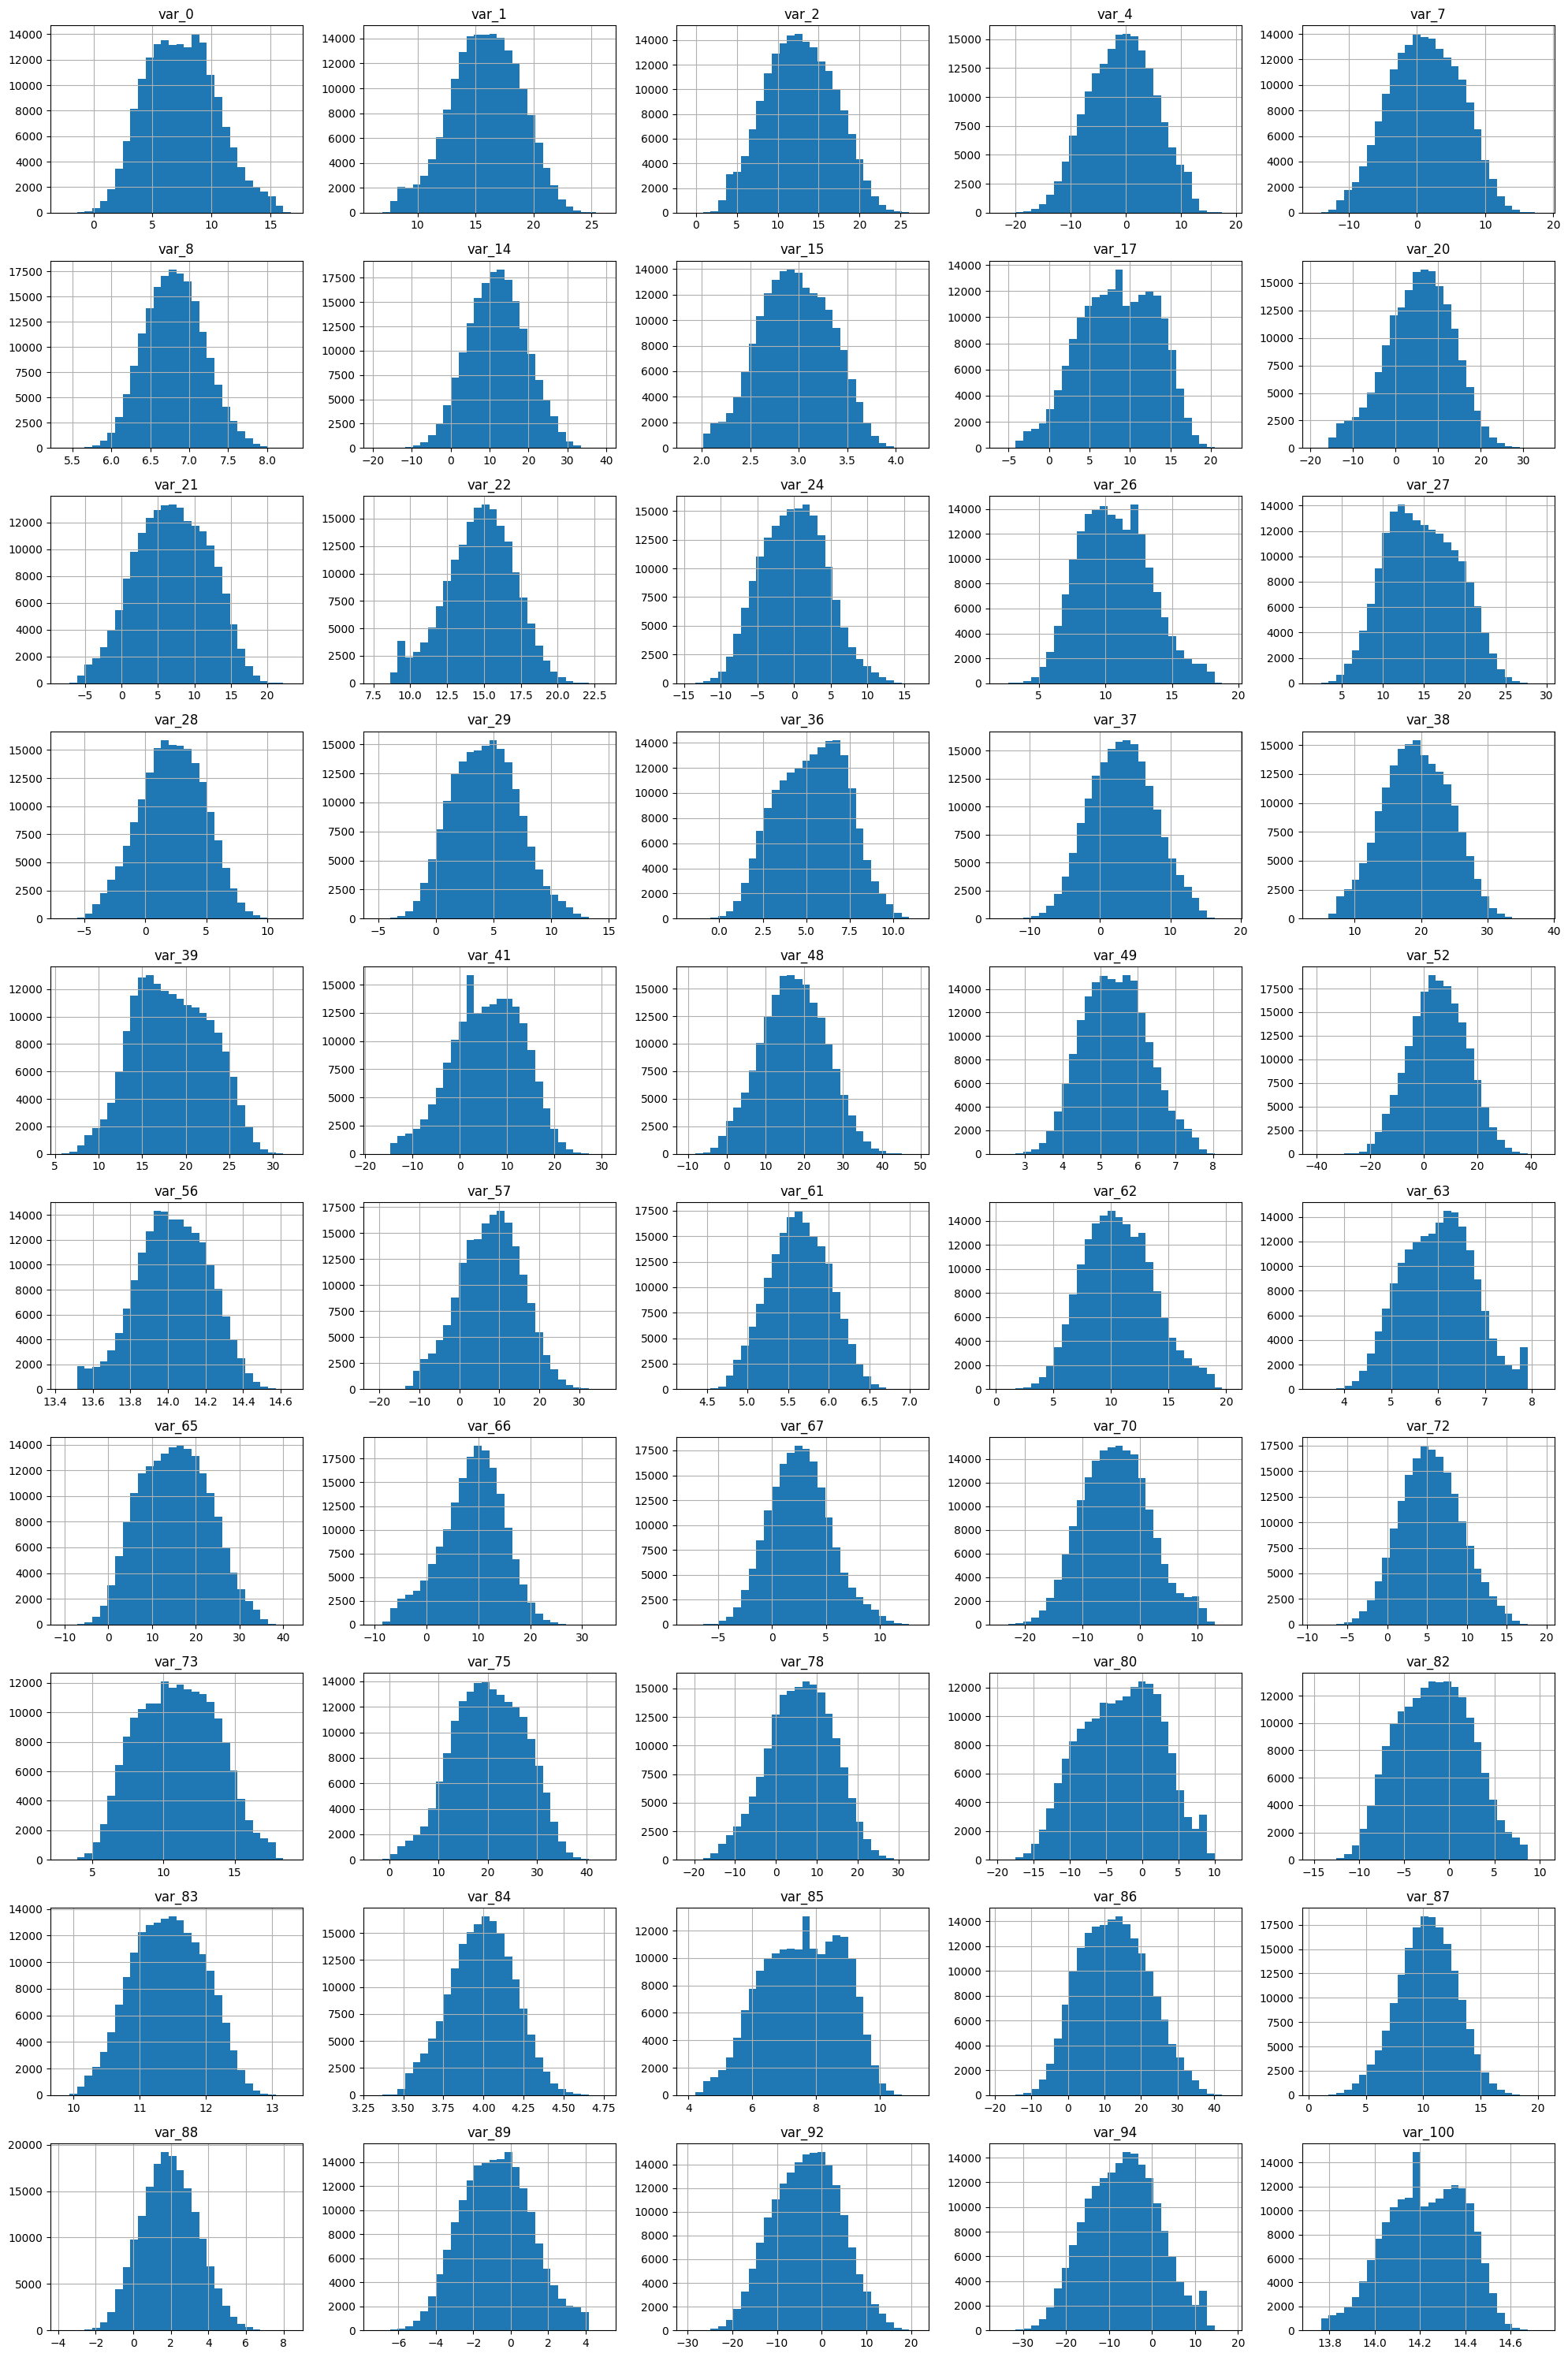

In [13]:
#disregard my target column for plotting and use method chaining to produce histogram plots of all remaining features
df.drop(columns=['target']).hist(bins=30, figsize=(20, 30), layout=(10, 5))
pyplot.tight_layout()
pyplot.show()

In [14]:
#verifying my target values are either 1s or 0s. Noticed they are floats. Cleaning in next cell before proceeding
df['target'].unique()

array([0., 1.])

In [15]:
#converts float target values to ints
df['target'] = df['target'].astype(int)

In [16]:
#verify cleaning
df['target'].unique()

array([0, 1])

### Checking Correlation Values

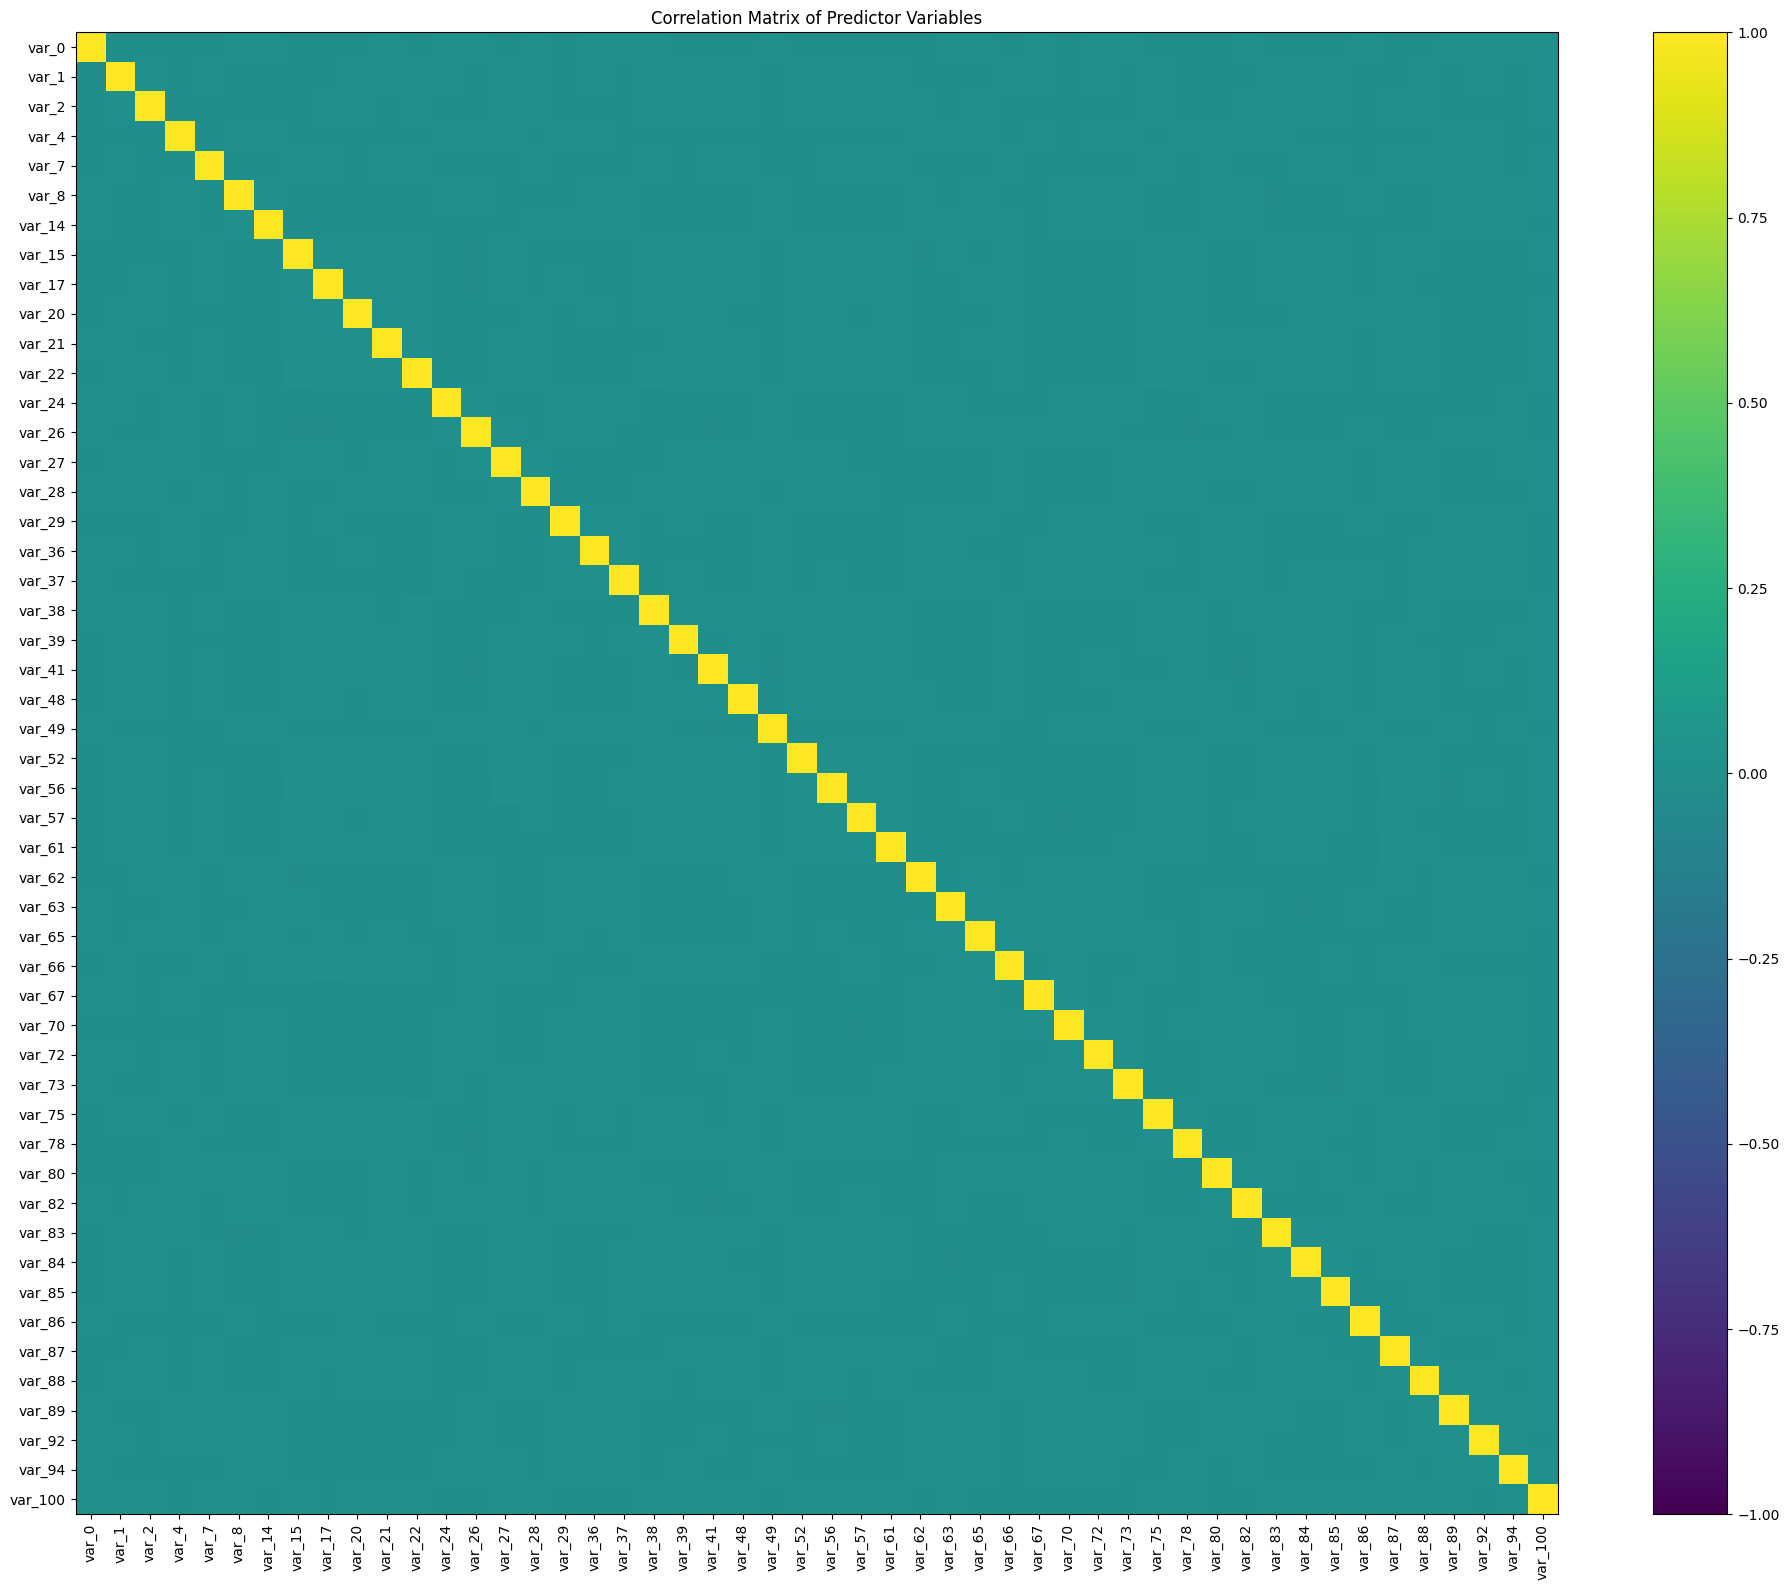

In [17]:
corr_matrix = df.drop(columns=['target']).corr()

pyplot.figure(figsize=(20, 16))
pyplot.imshow(corr_matrix, vmin=-1, vmax=1)
pyplot.colorbar()
pyplot.xticks(range(len(corr_matrix)), corr_matrix.columns, rotation=90)
pyplot.yticks(range(len(corr_matrix)), corr_matrix.columns)
pyplot.title('Correlation Matrix of Predictor Variables')
pyplot.tight_layout()
pyplot.show()

There is no correlation between any of the variables, but everything is correlated with itself which makes sense. All of these features are good candidates for GNB

In [18]:
#create two dataframes, one for successful transactions and another for unsuccessful transactions
df_success = df[df['target'] == 1].copy()
df_nosuccess = df[df['target'] == 0].copy()

In [19]:
#verify my dataframes
print(df_success.shape)
print(df_nosuccess.shape)

(18040, 51)
(161960, 51)


## Data Processing


With the data cleaned, the next step is to prepare it for modeling using Gaussian Naive Bayes.

- The predictor features (X) and target variable (y) are separated into distinct objects. The data is then split into training and testing subsets using an 80/20 split.

- Because the dataset is heavily imbalanced — roughly 90% non-transactions vs. 10% transactions — a balanced training set is also created by downsampling the majority class, which is critical for the model to learn both outcomes effectively.

In [20]:
#Seperating Predictor and Target Columns as Separate DataFrames
X = df.drop(columns=['target']).copy()
y = df['target'].copy()

In [21]:
#load gnb model
gnb = GaussianNB()

In [22]:
#split data into training and testing subsets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
#validate shape of training and testing subsets
[ _.shape for _ in [X_train, X_test, y_train, y_test] ]

[(144000, 50), (36000, 50), (144000,), (36000,)]

In [24]:
#train the model
gnb.fit(X_train, y_train);

In [25]:
#testing the model using our test subset
y_pred = gnb.predict(X_test)

In [26]:
#calculating accuracy using GNB score method
print(f"Accuracy: {gnb.score(X_test, y_test)}")

Accuracy: 0.9109166666666667


In [27]:
#cross validation loop
n = 100
results = np.zeros(n)

for i in range(n):
  ### TSS
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

  ### model
  gnb = GaussianNB()

  ### fit
  gnb.fit(X_train,y_train)

  ### prediction
  y_pred = gnb.predict(X_test)

  ### performance
  results[i] = 1-(y_test - y_pred).abs().mean()


In [28]:
print(results)

[0.91161111 0.91138889 0.91094444 0.91061111 0.91402778 0.90975
 0.91063889 0.91161111 0.91011111 0.91169444 0.91066667 0.909
 0.91186111 0.91319444 0.90925    0.91166667 0.91052778 0.91386111
 0.90941667 0.91119444 0.91169444 0.91127778 0.91080556 0.91166667
 0.90888889 0.91175    0.909      0.90988889 0.91086111 0.91266667
 0.91302778 0.90991667 0.91125    0.91041667 0.91216667 0.91111111
 0.91186111 0.91252778 0.91019444 0.91144444 0.91144444 0.90972222
 0.91052778 0.91152778 0.90880556 0.91047222 0.91266667 0.91238889
 0.91277778 0.91269444 0.91155556 0.90922222 0.91313889 0.91311111
 0.91358333 0.91333333 0.91136111 0.91258333 0.90988889 0.90897222
 0.91302778 0.91347222 0.91166667 0.91194444 0.91316667 0.91016667
 0.91227778 0.91291667 0.9145     0.91333333 0.91369444 0.91080556
 0.91108333 0.91141667 0.91241667 0.91077778 0.91083333 0.91108333
 0.91158333 0.91186111 0.91158333 0.90891667 0.91163889 0.90711111
 0.91108333 0.90947222 0.90911111 0.91244444 0.91208333 0.9115
 0.9110

In [29]:
#the accuracy is pretty close to what we got when we just ran it earlier
print(f"Cross-validation Accuracy: {results.mean():.4f}")
print(f"Std Dev: {results.std():.4f}")

Cross-validation Accuracy: 0.9113
Std Dev: 0.0014


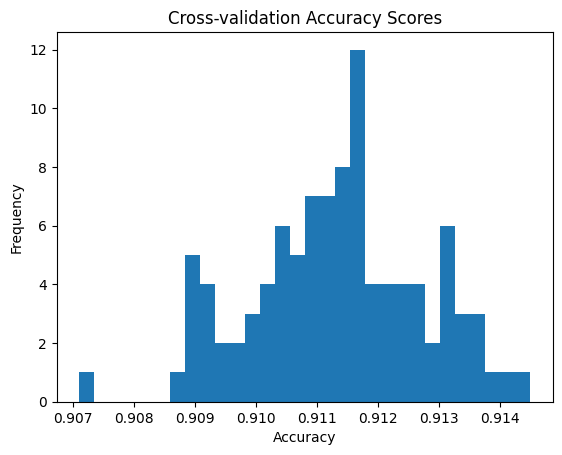

In [30]:
pyplot.hist(results, bins=30)
pyplot.title('Cross-validation Accuracy Scores')
pyplot.xlabel('Accuracy')
pyplot.ylabel('Frequency')
pyplot.show()

In [31]:
#this provides high precision, recall, and f1-score for unsuccessful transactions. However, the model performs poorly with these metrics for successful transactions
#therefore, we need to handle the uneven distribution of unsuccessful and successful transactions and run the model again for better performance to determine successful transactions
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[32046   396]
 [ 2711   847]]
              precision    recall  f1-score   support

           0       0.92      0.99      0.95     32442
           1       0.68      0.24      0.35      3558

    accuracy                           0.91     36000
   macro avg       0.80      0.61      0.65     36000
weighted avg       0.90      0.91      0.89     36000



In [32]:
# how many successful transactions do we have?
n_success = len(df_success)

# randomly sample that same number from unsuccessful
df_nosuccess_balanced = df_nosuccess.sample(n=n_success, random_state=42)

# combine them into a new balanced dataframe
df_balanced = pd.concat([df_success, df_nosuccess_balanced])

# verify the split
df_balanced['target'].value_counts()

,count
target,
1,18040
0,18040


In [33]:
X_balanced = df_balanced.drop(columns=['target']).copy()
y_balanced = df_balanced['target'].copy()

In [34]:
n = 100
results_balanced = np.zeros(n)

for i in range(n):
    X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.20)
    gnb = GaussianNB()
    gnb.fit(X_train, y_train)
    y_pred = gnb.predict(X_test)
    results_balanced[i] = gnb.score(X_test, y_test)

print(f"Balanced Cross-validation Accuracy: {results_balanced.mean():.4f}")
print(f"Std Dev: {results_balanced.std():.4f}")

Balanced Cross-validation Accuracy: 0.7527
Std Dev: 0.0045


## Data Visualization




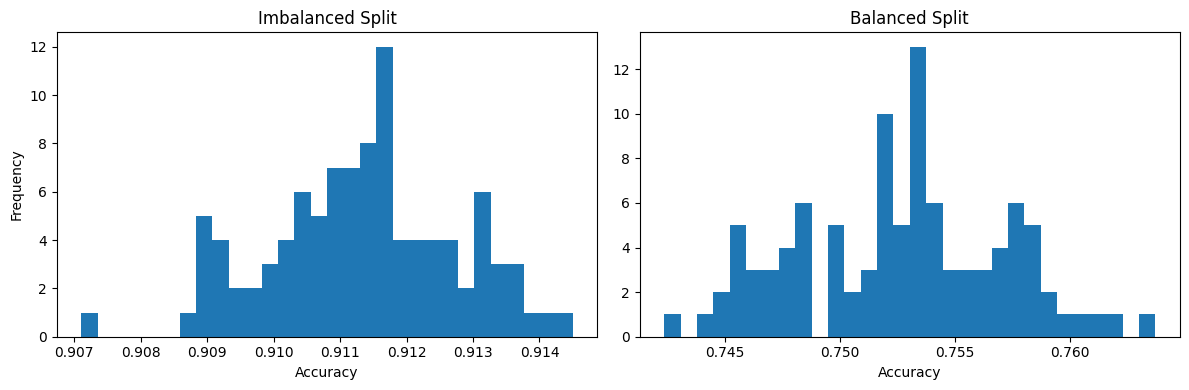

In [35]:
fig, (ax1, ax2) = pyplot.subplots(1, 2, figsize=(12, 4))

ax1.hist(results, bins=30)
ax1.set_title('Imbalanced Split')
ax1.set_xlabel('Accuracy')
ax1.set_ylabel('Frequency')

ax2.hist(results_balanced, bins=30)
ax2.set_title('Balanced Split')
ax2.set_xlabel('Accuracy')

pyplot.tight_layout()
pyplot.show()

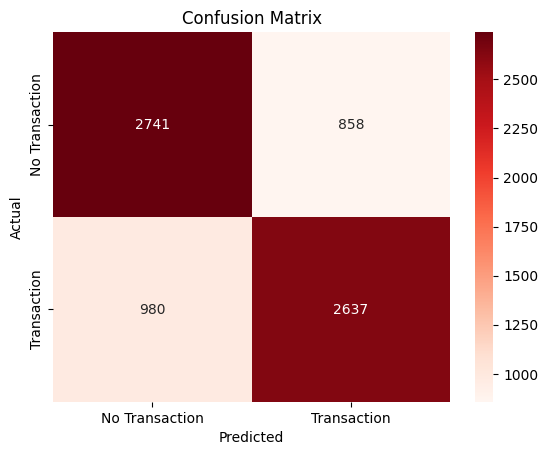

In [36]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['No Transaction', 'Transaction'],
            yticklabels=['No Transaction', 'Transaction'])
pyplot.title('Confusion Matrix')
pyplot.ylabel('Actual')
pyplot.xlabel('Predicted')
pyplot.show()

In [37]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.74      0.76      0.75      3599
           1       0.75      0.73      0.74      3617

    accuracy                           0.75      7216
   macro avg       0.75      0.75      0.75      7216
weighted avg       0.75      0.75      0.75      7216



## Communication of the Results

The goal of this project was to use anonymized customer transaction data to predict whether or not a customer will make a transaction using Gaussian Naive Bayes classification. Initially, the training data was heavily skewed toward non-transactions (90% negative, 10% positive), which caused the model to favor predicting non-transactions and perform poorly at identifying successful ones. After rebalancing the training data to a 50/50 split, the model became significantly more accurate at predicting successful transactions. This came at a slight cost to non-transaction prediction accuracy, which is an acceptable tradeoff since correctly identifying successful transactions is the primary objective of this problem.

